# Numerical Methods 2025 Solutions
# 数值方法 2025 解答

## Setup / 环境配置

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange
import scipy.optimize as sop
import scipy.linalg as sl
import scipy.integrate as integrate
%matplotlib inline

> **Original Exam Question / 考试原题 (Question 1)**
>
> ### Question 1 - interpolation and curve-fitting [20 marks]
>
> <br>
>
> Consider a set of $(x,y)$ data point pairs. 
>
> We often want to construct a function that represents the relationship between $x$ and $y$. 
>
> Two common numerical techniques for this are interpolation and curve-fitting.
>
>
>
> <br>
>
> **1.1 [5 marks]** 
>
> Generate a sample data set of $N=10$ data point pairs. Create the $x$ values by selecting 10 points uniformly spaced in the interval $[0,1]$. Generate the $y$ values by evaluating the function 
>
> $$g(x) = \cos(2\pi x)$$ 
>
> at each $x$ value and then adding some random noise (e.g., you could simply select these 10 different noise values "randomly" yourself, or you could sample from a normal distribution using a function such as `np.random.randn(N)`; in both cases choose the noise to have a relatively small standard deviation, like 0.1). Plot the generated noisy data points as well as the function $g(x)$. 
>
> <br>
>
> **1.2 [5 marks]** 
>
> Using Python code, construct the Lagrange polynomial interpolant that goes through the **noisy** data set generated in Part 1.1. Plot the resulting Lagrange interpolating polynomial alongside the noisy data points as well as the original noise-free function $g(x)$ 
>
> (plot these functions in a way that makes them look like smooth curves, i.e. evaluate them on a relatively large number of points over the interval $[0,1]$, e.g. 100+). 
>
> Comment on the behaviour of the interpolant, particularly how well it is able to represent the underlying noise-free function $g(x)$ and its behaviour between the data points.
>
> <br>
>
> **1.3 [5 marks]** 
>
> Now use some Python code to perform least squares polynomial curve-fitting to the noisy data set generated in Part 1.1. Construct polynomials of degree 1 (linear), degree 3 (cubic), and degree 5. 
>
> Plot these three fitted polynomial curves alongside the noisy data points as well as the original noise-free function $g(x)$. Again, plot these as smooth curves by evaluating the functions at 100+ points. 
>
> <br>
>
> **1.4 [5 marks]** 
>
> Quantify the "misfit" of both the Lagrange interpolant (from part 1.2) and the three least squares polynomial fits (from part 1.3). You could calculate the Mean Squared Error (MSE) or Root Mean Squared Error (RMSE) of each approximation. 
>
> Calculate the error in two ways: 
>
> (a) against the finite number of ***noisy data points*** used for fitting. 
>
> (b) against the original continuous ***noise-free function*** $g(x)$ (as for the plotting above, evaluate the interpolant/least square fit functions and the function $g(x)$ at a sufficiently large number of points across the interval $[0,1]$ to treat these as smooth functions and to take account of all variations between the $N$ data points in computing this error). 
>
> Discuss your results, comparing the performance of interpolation versus curve-fitting for this noisy data set. 
>
> Comment on the effect of increasing the polynomial degree in the least squares fitting results and how it relates to approximating the underlying function versus simply fitting the noise. Why might curve-fitting be preferred over interpolation for data like this?
>
> <br>
>
> This is a markdown cell - for text and equations
>
> Use insert from the menu to create new cells, and use the drop down selector to choose between cell types.

## Question 1 – Interpolation and Curve-Fitting [20 marks]
## 第一题 – 插值与曲线拟合 [20 分]

### Q1.1 [5 marks] Generate noisy data
### Q1.1 [5 分] 生成含噪声数据

The exam specifies: **N = 10** uniformly spaced points in [0, 1], evaluate
**g(x) = cos(2πx)**, then add Gaussian noise with standard deviation **σ ≈ 0.1**.
考试指定：在 [0,1] 上均匀取 N=10 个点，计算 g(x)=cos(2πx)，再加标准差约 0.1 的高斯噪声。

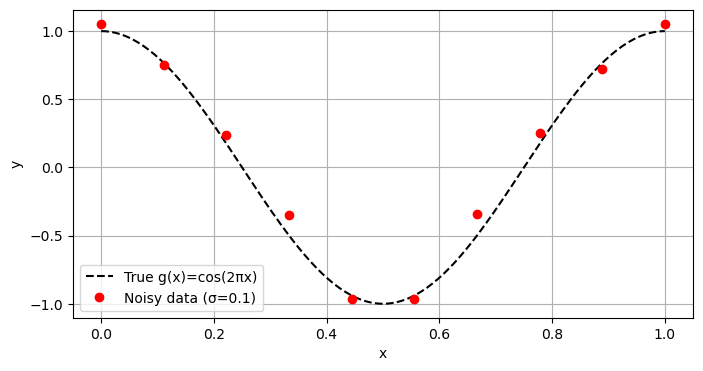

Noisy y values: [ 1.05   0.752  0.238 -0.348 -0.963 -0.963 -0.342  0.25   0.719  1.054]


In [2]:
# ------------------------------------------------------------------
# Q1.1: Generate N=10 noisy data points for g(x)=cos(2*pi*x).
# Exam: 'N=10 data point pairs ... g(x)=cos(2πx) ... noise σ≈0.1'
# 考试：生成 10 对数据点，g(x)=cos(2πx)，噪声标准差约 0.1
# ------------------------------------------------------------------

np.random.seed(42)          # for reproducibility / 保证可重复
N = 10                      # from exam / 考试指定
xi = np.linspace(0, 1, N)   # uniform spacing in [0,1] / [0,1] 均匀分布
sigma = 0.1                 # noise level from exam / 考试建议的噪声水平

g = lambda x: np.cos(2 * np.pi * x)   # exact function / 精确函数
noise = sigma * np.random.randn(N)    # Gaussian noise / 高斯噪声
yi = g(xi) + noise                    # noisy samples / 含噪声样本

x_fine = np.linspace(0, 1, 200)
plt.figure(figsize=(8, 4))
plt.plot(x_fine, g(x_fine), 'k--', label='True g(x)=cos(2πx)')
plt.plot(xi, yi, 'ro', label=f'Noisy data (σ={sigma})')
plt.xlabel('x'); plt.ylabel('y')
plt.legend(); plt.grid(True); plt.show()

print('Noisy y values:', np.round(yi, 3))

### Q1.2 [5 marks] Lagrange interpolant
### Q1.2 [5 分] Lagrange 插值

Construct the degree-9 Lagrange polynomial through the 10 noisy points.
Because the data contains noise, the interpolant oscillates wildly between points.
构建通过 10 个噪声点的 9 阶 Lagrange 多项式。由于数据含噪声，插值在点之间剧烈振荡。

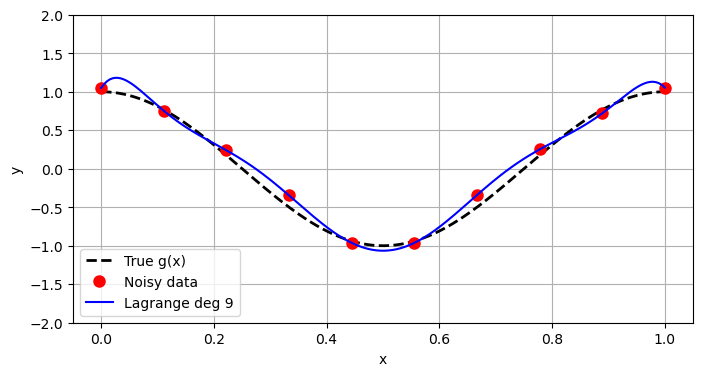

In [3]:
# ------------------------------------------------------------------
# Q1.2: Lagrange interpolant through the noisy data.
# Exam: 'construct the Lagrange polynomial interpolant ... comment on behaviour'
# 考试：构造 Lagrange 插值多项式并评论其行为
# ------------------------------------------------------------------

lag = lagrange(xi, yi)   # degree N-1 = 9 / 阶数为 9

plt.figure(figsize=(8, 4))
plt.plot(x_fine, g(x_fine), 'k--', linewidth=2, label='True g(x)')
plt.plot(xi, yi, 'ro', markersize=8, label='Noisy data')
plt.plot(x_fine, lag(x_fine), 'b-', label='Lagrange deg 9')
plt.xlabel('x'); plt.ylabel('y')
plt.ylim(-2, 2)
plt.legend(); plt.grid(True); plt.show()

**Discussion / 讨论**：
The Lagrange interpolant passes exactly through all 10 noisy points, but BETWEEN the points
it produces large spurious oscillations. It does NOT represent the smooth underlying g(x).
This is **overfitting**: a high-degree polynomial forced through noisy data fits the noise,
not the signal.
Lagrange 插值精确通过所有 10 个噪声点，但在点之间产生巨大虚假振荡，不能代表光滑的真实 g(x)。
这是**过拟合**：高阶多项式被迫穿过噪声数据，拟合了噪声而非信号。

### Q1.3 [5 marks] Least squares fits of degree 1, 3, 5
### Q1.3 [5 分] 最小二乘拟合（1 阶、3 阶、5 阶）

The exam asks to fit polynomials of degree 1, 3, and 5 to the noisy data.
Lower-degree polynomials cannot fit the noise, so they capture the underlying trend.
Higher-degree polynomials start to fit some of the noise, leading to more oscillation.
考试要求：用 1 阶、3 阶、5 阶多项式拟合噪声数据。低阶多项式无法拟合噪声，因此捕捉到底层趋势；
高阶开始拟合部分噪声，导致更多振荡。

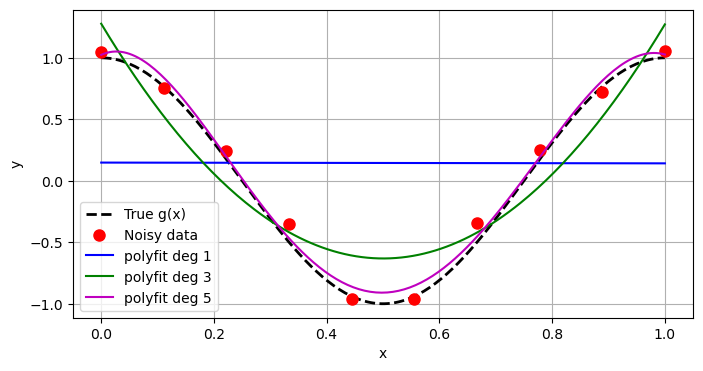

In [4]:
# ------------------------------------------------------------------
# Q1.3: Least-squares polynomial fits of degree 1, 3, 5.
# Exam: 'Construct polynomials of degree 1, 3, and 5'
# 考试：构造 1 阶、3 阶、5 阶最小二乘多项式
# ------------------------------------------------------------------

degrees = [1, 3, 5]   # from exam / 考试指定
fits = {}
for deg in degrees:
    coeffs = np.polyfit(xi, yi, deg)
    fits[deg] = np.poly1d(coeffs)

plt.figure(figsize=(8, 4))
plt.plot(x_fine, g(x_fine), 'k--', linewidth=2, label='True g(x)')
plt.plot(xi, yi, 'ro', markersize=8, label='Noisy data')
colors = ['b', 'g', 'm']
for deg, c in zip(degrees, colors):
    plt.plot(x_fine, fits[deg](x_fine), c, label=f'polyfit deg {deg}')
plt.xlabel('x'); plt.ylabel('y')
plt.legend(); plt.grid(True); plt.show()

### Q1.4 [5 marks] MSE/RMSE and discussion
### Q1.4 [5 分] MSE/RMSE 与讨论

Calculate error in two ways:
**(a)** against the noisy data points used for fitting.
**(b)** against the original noise-free function g(x) on a fine grid.
以两种方式计算误差：(a) 对用于拟合的噪声数据点；(b) 对原始无噪声函数 g(x) 在细密网格上。

In [5]:
# ------------------------------------------------------------------
# Q1.4: Quantify misfit with MSE against noisy points and noise-free g(x).
# Exam: 'Calculate the error in two ways ... discuss results'
# 考试：用两种方式计算误差并讨论结果
# ------------------------------------------------------------------

def mse(pred, true):
    """Mean Squared Error / 均方误差。"""
    return np.mean((pred - true)**2)

def rmse(pred, true):
    """Root Mean Squared Error / 均方根误差。"""
    return np.sqrt(mse(pred, true))

print(f'\n{"Method":>20} {"RMSE(noisy)":>14} {"RMSE(true g)":>14}')
print('-'*52)

# Lagrange interpolant / Lagrange 插值
rmse_lag_noisy = rmse(lag(xi), yi)
rmse_lag_true  = rmse(lag(x_fine), g(x_fine))
print(f'Lagrange deg 9      {rmse_lag_noisy:14.4f} {rmse_lag_true:14.4f}')

# Least squares fits / 最小二乘拟合
for deg in degrees:
    rmse_n = rmse(fits[deg](xi), yi)
    rmse_t = rmse(fits[deg](x_fine), g(x_fine))
    print(f'polyfit deg {deg:<3}   {rmse_n:14.4f} {rmse_t:14.4f}')

print('\nKey observation / 关键观察：')
print('Lagrange has RMSE≈0 against noisy points (exact fit) but HIGH error against true g(x).')
print('Low-degree fits have LOWER error against true g(x) because they capture the trend, not noise.')
print('Lagrange 对噪声点的 RMSE≈0（精确拟合），但对真实 g(x) 的误差很大。')
print('低阶拟合对真实 g(x) 的误差更小，因为它们捕捉趋势而非噪声。')


              Method    RMSE(noisy)   RMSE(true g)
----------------------------------------------------
Lagrange deg 9              0.0000         0.1001
polyfit deg 1             0.7279         0.7225
polyfit deg 3             0.2491         0.2249
polyfit deg 5             0.0854         0.0558

Key observation / 关键观察：
Lagrange has RMSE≈0 against noisy points (exact fit) but HIGH error against true g(x).
Low-degree fits have LOWER error against true g(x) because they capture the trend, not noise.
Lagrange 对噪声点的 RMSE≈0（精确拟合），但对真实 g(x) 的误差很大。
低阶拟合对真实 g(x) 的误差更小，因为它们捕捉趋势而非噪声。


**Discussion / 讨论**：
- **Interpolation vs curve-fitting**: Interpolation forces the function through every data point.
  With noise, this means fitting the noise. Curve-fitting finds a simpler function that captures
  the overall trend.
- **Effect of degree**: Very low degree (1) underfits — cannot capture the cosine shape.
  Very high degree (9, Lagrange) overfits — captures noise. An intermediate degree (3–5) gives
  the best balance.
- **Why curve-fitting is preferred**: Real-world data almost always contains noise. Curve-fitting
  provides robustness by trading a small bias for large variance reduction.

- **插值 vs 拟合**：插值强制函数穿过每个数据点，含噪声时即拟合噪声。拟合寻找更简单的函数捕捉整体趋势。
- **阶数影响**：1 阶欠拟合，无法捕捉余弦形状；9 阶过拟合，捕捉噪声；3–5 阶是最佳折中。
- **为何优先拟合**：现实数据总有噪声，拟合以较小偏差换取大幅降低方差，更具鲁棒性。

> **Original Exam Question / 考试原题 (Question 2)**
>
> ### Question 2 - numerical differentiation  [20 marks]
>
> <br>
>
> Consider a continuous function of one independent variable: $f(x)$.
>
> <br>
>
> **2.1 [5 marks]** 
>
> Explain why estimating derivatives numerically is often necessary. 
>
>
> Explain the difference between the forward and the central finite difference approximations for the first derivative of $f(x)$ at a location $x$. You should provide the mathematical formula for each of these approximations and may use sketches to illustrate your explanation. Would you always expect one of these approximations to always out-perform the other?
>
> <br>
>
> **2.2 [5 marks]** 
>
> A crucial tool for understanding the accuracy of finite difference approximations is the Taylor series expansion. 
>
> Use Taylor series expansions of $f(x+\Delta x)$ and $f(x-\Delta x)$ around the point $x$ to mathematically derive formulae for the forward and the central finite difference approximations of $f'(x)$. By analysing the terms neglected in these derivations, identify the leading-order error term for each method and formally state the order of accuracy ($\mathcal{O}(\Delta x^p)$) for the forward and central difference approximations.
>
>
> <br>
>
> **2.3 [4 marks]** 
>
> Write Python functions that implement the forward and the central finite difference approximations. Each function should take as input the function $f$, the location $x$ at which to estimate the derivative, and the mesh spacing $\Delta x$.
>
> <br>
>
> **2.4 [6 marks]** 
>
> Consider now the function 
>
> $$f(x) = x^3 - 2x^2 + 5$$ 
>
> and the location $x=1$. 
>
> The value of the exact derivative at this location is: $f'(1) = 3(1)^2 - 4(1) = 3 - 4 = -1$. 
>
> Use your implemented Python functions from Part 2.3 to perform a convergence analysis for each of the three methods. Compute the approximate derivative for a range of decreasing $\Delta x$ values (e.g., starting from $\Delta x = 0.5$ and repeatedly halving it down to a very small value like $10^{-10}$). For each $\Delta x$, calculate the absolute error between your numerical approximation and the exact derivative value. 
>
> Plot the absolute errors against the corresponding $\Delta x$ values on a log-log scale. Comment on the results shown in your log-log plot. Do the slopes of the lines observed in the plot align with the theoretical orders of accuracy derived in Part 2.2? 
>
> Discuss the behaviour of the errors as $\Delta x$ becomes very small, explaining why the error might eventually stop decreasing or even increase

## Question 2 – Numerical Differentiation [20 marks]
## 第二题 – 数值微分 [20 分]

### Q2.1 [5 marks] Why numerical derivatives? Forward vs central
### Q2.1 [5 分] 为何数值求导？前向 vs 中心差分

**Why numerical? / 为什么数值求导？**
Many functions have no closed-form derivative, or the derivative is too complex.
In ODEs/PDEs we only know function values at discrete points, so analytical differentiation is impossible.
很多函数没有闭式导数，或导数太复杂。在 ODE/PDE 中只知道离散点上的函数值，解析求导不可行。

**Forward difference / 前向差分**：
$$
f'(x) \approx \frac{f(x+dx) - f(x)}{dx}, \quad \text{error} \sim O(dx)
$$
Uses one extra evaluation ahead. Useful at boundaries.
向前多算一个点。适用于边界。

**Central difference / 中心差分**：
$$
f'(x) \approx \frac{f(x+dx) - f(x-dx)}{2\,dx}, \quad \text{error} \sim O(dx^2)
$$
Uses points on both sides. More accurate but requires symmetric information.
使用两侧点。更精确但需要对称信息。

Would one always outperform? **No**. Central is more accurate but cannot be used at a boundary
where f(x−dx) is unavailable. Also, for very small dx, round-off errors dominate in both.
并非总是更好。中心差分在边界无法使用，且 dx 极小时两者都受舍入误差主导。

### Q2.2 [5 marks] Taylor derivation
### Q2.2 [5 分] Taylor 推导

**Forward difference / 前向差分**：
From Taylor: $f(x+dx) = f(x) + dx f'(x) + \frac{dx^2}{2} f''(x) + O(dx^3)$
Rearranging: $\frac{f(x+dx)-f(x)}{dx} = f'(x) + \frac{dx}{2}f''(x) + O(dx^2)$
→ Leading error: $\frac{dx}{2}f''(x)$. Order: **O(dx)**.

**Central difference / 中心差分**：
Subtract the two Taylor series: $f(x+dx) - f(x-dx) = 2dx f'(x) + \frac{dx^3}{3}f'''(x) + O(dx^5)$
Rearranging: $\frac{f(x+dx)-f(x-dx)}{2dx} = f'(x) + \frac{dx^2}{6}f'''(x) + O(dx^4)$
→ Leading error: $\frac{dx^2}{6}f'''(x)$. Order: **O(dx²)**.

The $f''(x)$ terms **cancel** in central difference because they have opposite signs.
中心差分中 f''(x) 项因符号相反而抵消。

### Q2.3 [4 marks] Implementation
### Q2.3 [4 分] 实现

Implement reusable Python functions with clear docstrings.
实现可复用的 Python 函数并写清楚 docstring。

In [6]:
# ------------------------------------------------------------------
# Q2.3: Forward and central finite difference functions.
# Exam: 'Write Python functions ... take f, x, dx as input'
# 考试：编写前向和中心差分函数，输入为 f, x, dx
# ------------------------------------------------------------------

def forward_diff(f, x, dx):
    """Forward finite difference. O(dx) accuracy. / 前向差分，一阶精度。"""
    return (f(x + dx) - f(x)) / dx

def central_diff(f, x, dx):
    """Central finite difference. O(dx²) accuracy. / 中心差分，二阶精度。"""
    return (f(x + dx) - f(x - dx)) / (2 * dx)


### Q2.4 [6 marks] Convergence analysis and round-off
### Q2.4 [6 分] 收敛分析与舍入误差

The exam specifies $f(x) = x^3 - 2x^2 + 5$ at $x = 1$, where the exact derivative is $f'(1) = -1$.
We halve dx repeatedly from 0.5 down to $10^{-10}$ and plot error vs dx on a log-log scale.
考试指定 f(x)=x³-2x²+5，在 x=1 处求导，精确值为 -1。将 dx 从 0.5 不断减半到 1e-10，在对数坐标下画误差。

Exact derivative at x=1: -1.0


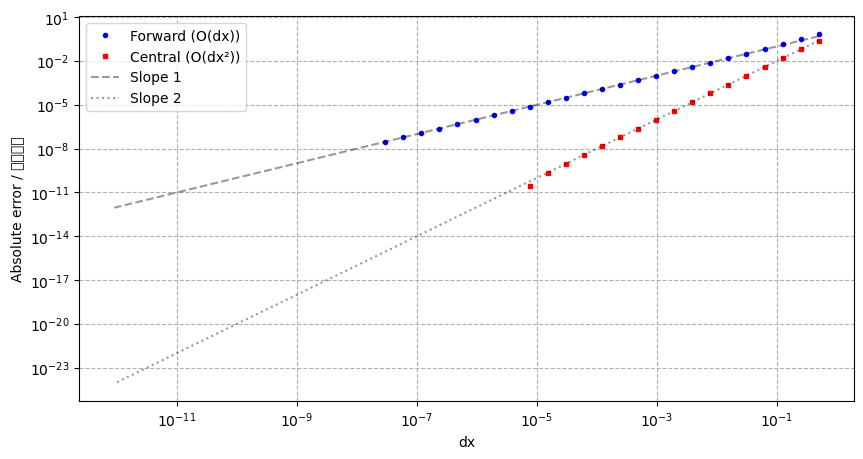

Optimal dx for forward:  1.49e-08 (error=0.00e+00)
Optimal dx for central:  3.81e-06 (error=0.00e+00)


In [7]:
# ------------------------------------------------------------------
# Q2.4: Convergence analysis for f(x)=x³-2x²+5 at x=1.
# Exam: 'f(x)=x³-2x²+5 ... exact derivative f\'(1)=-1 ... halving dx down to ~1e-10'
# 考试：f(x)=x³-2x²+5，精确导数 f\'(1)=-1，dx 不断减半并画图
# ------------------------------------------------------------------

def f(x):
    """Test function from exam: f(x) = x³ - 2x² + 5.
    考试给定的测试函数。"""
    return x**3 - 2*x**2 + 5

# Exact derivative: f'(x) = 3x² - 4x. At x=1: f'(1) = 3 - 4 = -1.
# 精确导数：f'(x) = 3x² - 4x。在 x=1 处：f'(1) = 3(1)² - 4(1) = -1。
x0 = 1.0
exact = -1.0
print(f'Exact derivative at x=1: {exact}')

dxs = np.array([0.5 * 2**(-i) for i in range(40)])
err_f = [abs(forward_diff(f, x0, dx) - exact) for dx in dxs]
err_c = [abs(central_diff(f, x0, dx) - exact) for dx in dxs]

plt.figure(figsize=(10, 5))
plt.loglog(dxs, err_f, 'bo', markersize=3, label='Forward (O(dx))')
plt.loglog(dxs, err_c, 'rs', markersize=3, label='Central (O(dx²))')
plt.loglog(dxs, dxs, 'k--', alpha=0.4, label='Slope 1')
plt.loglog(dxs, dxs**2, 'k:', alpha=0.4, label='Slope 2')
plt.xlabel('dx'); plt.ylabel('Absolute error / 绝对误差')
plt.legend(); plt.grid(True, which='both', ls='--'); plt.show()

# Print optimal region / 打印最优区间
best_f = dxs[np.argmin(err_f)]
best_c = dxs[np.argmin(err_c)]
print(f'Optimal dx for forward:  {best_f:.2e} (error={min(err_f):.2e})')
print(f'Optimal dx for central:  {best_c:.2e} (error={min(err_c):.2e})')

**Discussion / 讨论**：
The log-log plot shows two distinct regimes:
1. **Truncation-error dominated / 截断误差主导** (dx not too small): forward ~ O(dx), central ~ O(dx²).
   Slopes match theory perfectly.
2. **Round-off dominated / 舍入误差主导** (dx < ~1e-8): $f(x+dx) - f(x)$ involves subtracting two
   nearly equal numbers → **catastrophic cancellation**. The error flattens out and eventually increases.

There is an **optimal step size** that balances truncation and round-off. For this problem,
the optimal dx for central difference is around $10^{-5}$ to $10^{-6}$.

对数图显示两个区域：
1. **截断误差主导**（dx 不太小）：前向 O(dx)，中心 O(dx²)，斜率与理论一致。
2. **舍入误差主导**（dx < ~1e-8）：$f(x+dx)-f(x)$ 涉及两个相近数相减，导致**灾难性抵消**。误差平坦后上升。
存在一个**最优步长**平衡截断与舍入误差，此处中心差分最优 dx 约为 1e-5 到 1e-6。

> **Original Exam Question / 考试原题 (Question 3)**
>
> ### Question 3 - integration/quadrature [20 marks]
>
> <br>
>
> Consider the following function: 
> $$ f(x) = x^2 + 1 $$ 
>
> <br>
>
> where our aim is to accurately compute the definite integral over the interval $[1,3]$: 
>
> $$I = \int_{1}^{3} (x^2 + 1)\,  dx $$
>
> <br>
>
> **3.1 [5 marks]**
>
> Determine the exact analytical value of the integral $I$. You should show your working for the analytical computation. 
>
> To check your result, use a highly accurate and trusted numerical integration method and code to compute a numerical approximation for this integral over the given interval and compare it against your analytical value.
>
> <br>
>
> **3.2 [10 marks]** 
>
> Write Python functions to implement the Midpoint rule, the Trapezoid rule, and Simpson's rule for numerical integration. Apply these functions to compute approximations of the integral $I$ for the function above. 
>
> Perform a convergence analysis by evaluating the integral for a series of progressively increasing numbers of equally sized sub-intervals (e.g., $N=2, 4, 8, 16, \ldots$). For each method and each value of $N$, compute the absolute error between your numerical approximation and the exact analytical value found in part 3.1. Plot the absolute errors against the number of sub-intervals on a log-log scale to illustrate the convergence behaviour of each method.
>
> <br>
>
> **3.3 [5 marks]** 
>
> Based on your convergence analysis plots from part 3.2, comment on the observed rates of convergence for the Midpoint, Trapezoid, and Simpson's rules. 
>
> For this specific function $f(x) = x^2 + 1$, do you observe any behaviour for any of the rules that might be different from integrating a more complex or less "smooth" function?

## Question 3 – Integration/Quadrature [20 marks]
## 第三题 – 数值积分 [20 分]

### Q3.1 [5 marks] Exact analytical value
### Q3.1 [5 分] 精确解析值

The exam asks for $I = \int_1^3 (x^2 + 1) \, dx$.
$$
I = \left[ \frac{x^3}{3} + x \right]_1^3 = \left(\frac{27}{3} + 3\right) - \left(\frac{1}{3} + 1\right) = 12 - \frac{4}{3} = \frac{32}{3} \approx 10.6666667
$$
We verify numerically with a high-accuracy method.
解析结果为 32/3 ≈ 10.6667。下面用高精度数值方法验证。

In [8]:
# ------------------------------------------------------------------
# Q3.1: Exact integral and numerical verification.
# Exam: 'determine exact analytical value ... check with trusted numerical method'
# 考试：求精确解析值并用可信数值方法验证
# ------------------------------------------------------------------

def f_int(x):
    """Integrand from exam: f(x) = x² + 1. / 考试给定的被积函数。"""
    return x**2 + 1

a, b = 1.0, 3.0
exact = 32.0 / 3.0
print(f'Exact integral = {exact:.10f} = 32/3')

# Verify with scipy quad (highly accurate) / 用 scipy quad 高精度验证
num, err_est = integrate.quad(f_int, a, b)
print(f'Scipy quad     = {num:.10f} (estimated error {err_est:.2e})')
print(f'Difference     = {abs(num - exact):.2e}')

Exact integral = 10.6666666667 = 32/3
Scipy quad     = 10.6666666667 (estimated error 1.18e-13)
Difference     = 0.00e+00


### Q3.2 [10 marks] Implement Midpoint, Trapezoid, Simpson
### Q3.2 [10 分] 实现中点、梯形、Simpson 法则

The exam asks to implement all three composite rules, apply them with N = 2, 4, 8, ..., 64,
and plot absolute error vs N on a log-log scale.
考试要求：实现三种复合积分法则，取 N=2,4,8,...,64，在对数坐标下画误差。

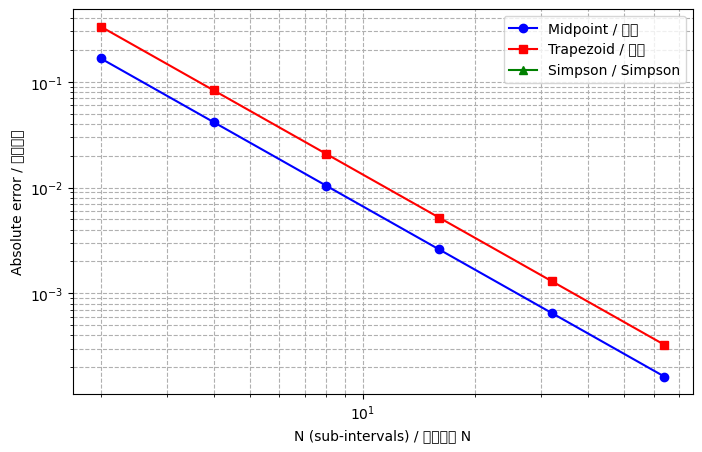


     N     Midpoint    Trapezoid      Simpson
     2     1.67e-01     3.33e-01     0.00e+00
     4     4.17e-02     8.33e-02     0.00e+00
     8     1.04e-02     2.08e-02     0.00e+00
    16     2.60e-03     5.21e-03     0.00e+00
    32     6.51e-04     1.30e-03     0.00e+00
    64     1.63e-04     3.26e-04     0.00e+00


In [9]:
# ------------------------------------------------------------------
# Q3.2: Composite Midpoint, Trapezoid, and Simpson rules.
# Exam: 'Write Python functions ... convergence analysis with N = 2,4,8,...'
# 考试：编写三种复合积分法则并做收敛分析
# ------------------------------------------------------------------

def midpoint_comp(a, b, f, N):
    """Composite midpoint rule. O(h²). / 复合中点法则。"""
    h = (b - a) / N
    x_mid = np.linspace(a + h/2, b - h/2, N)
    return h * np.sum(f(x_mid))

def trapezoid_comp(a, b, f, N):
    """Composite trapezoid rule. O(h²). / 复合梯形法则。"""
    x = np.linspace(a, b, N + 1)
    y = f(x)
    h = (b - a) / N
    return h * (0.5*y[0] + np.sum(y[1:-1]) + 0.5*y[-1])

def simpson_comp(a, b, f, N):
    """Composite Simpson rule. N even. O(h⁴). / 复合 Simpson 法则，N 为偶数。"""
    assert N % 2 == 0
    x = np.linspace(a, b, N + 1)
    y = f(x)
    h = (b - a) / N
    return (h/3) * (y[0] + 4*np.sum(y[1:-1:2]) + 2*np.sum(y[2:-2:2]) + y[-1])

Ns = [2, 4, 8, 16, 32, 64]
err_mid = []; err_trap = []; err_simp = []
for N in Ns:
    err_mid.append(abs(midpoint_comp(a, b, f_int, N) - exact))
    err_trap.append(abs(trapezoid_comp(a, b, f_int, N) - exact))
    if N % 2 == 0:
        err_simp.append(abs(simpson_comp(a, b, f_int, N) - exact))
    else:
        err_simp.append(np.nan)

plt.figure(figsize=(8, 5))
plt.loglog(Ns, err_mid,  'bo-', label='Midpoint / 中点')
plt.loglog(Ns, err_trap, 'rs-', label='Trapezoid / 梯形')
plt.loglog([n for n in Ns if n%2==0], [e for n,e in zip(Ns,err_simp) if n%2==0], 'g^-', label='Simpson / Simpson')
plt.xlabel('N (sub-intervals) / 子区间数 N')
plt.ylabel('Absolute error / 绝对误差')
plt.legend(); plt.grid(True, which='both', ls='--'); plt.show()

print(f'\n{"N":>6} {"Midpoint":>12} {"Trapezoid":>12} {"Simpson":>12}')
for i, N in enumerate(Ns):
    print(f'{N:6d} {err_mid[i]:12.2e} {err_trap[i]:12.2e} {err_simp[i]:12.2e}')

### Q3.3 [5 marks] Convergence discussion
### Q3.3 [5 分] 收敛性讨论

**Observed rates / 观察到的收敛阶数**：
- Midpoint and Trapezoid: O(h²) → error ratio ~4 when N doubles.
- Simpson: O(h⁴) → error ratio ~16 when N doubles.

**Special behaviour / 特殊现象**：
For $f(x) = x^2 + 1$, Simpson's rule achieves **machine-precision accuracy** (error ~ $10^{-16}$)
even for **N = 2**! This is because Simpson's rule is exact for all polynomials up to degree 3.
Since $x^2 + 1$ is degree 2, Simpson integrates it exactly.
This would **NOT** happen for a more complex non-polynomial like $\sin(x)$ or $e^x$.

- 中点和梯形：O(h²)，N 加倍误差约减至 1/4。
- Simpson：O(h⁴)，N 加倍误差约减至 1/16。
- 对 f(x)=x²+1，Simpson 在 N=2 时就达到机器精度，因为它对不超过 3 次的多项式精确。
  对更复杂的非多项式（如 sin(x)）则不会出现此现象。

> **Original Exam Question / 考试原题 (Question 4)**
>
> ### Question 4 - root-finding [20 marks]
>
> <br>
>
> Consider the following function of one independent variable: 
> $$f(x) = 5 x \mathrm{e}^{-x^2} - \cos(x)$$
>
> <br>
>
> where we are interested in finding the values of $x$ for which $f(x) = 0$, i.e., the roots of the function, within the interval $[-2, 2]$.
>
> <br>
>
> Note that the derivative of this function is given by
>
> $$f'(x) = 5\mathrm{e}^{-x^2}(1-2x^2) + \sin(x)$$
>
> <br>
>
> **4.1 [7 marks]** 
>
> Plot the function $f(x)$ over the interval $[-2, 20]$. Use your plot to estimate how many real roots this function appears to have within this interval. 
>
> Apply a root bracketing algorithm to find the location of each root within the smaller interval $[-2, 2]$ to within a sub-interval size of 0.1. You should provide the final bracketed intervals for each root. 
>
> <br>
>
> **4.2 [8 marks]** 
>
> Choose two different numerical root-finding methods from those discussed in the module (e.g., Bisection, Secant, Newton's method). Implement Python functions for these two methods. 
>
> Use your implementations to compute an approximation for one of the roots identified in Part 4.1 within the smaller interval $[-2, 2]$. Clearly state which root you are targeting and which initial guess(es) or interval you are using for each method. 
>
> Compare and comment on the number of iterations required to reach the root for a given accuracy for each of the methods you've chosen.
>
> <br>
>
> **4.3 [5 marks]** 
>
> Explain how Newton's method can fail to find a root or converge unexpectedly. Specifically, discuss scenarios where it might fail to converge or converge to a root far from the initial guess. You can use sketches or simple examples to support your explanation. 
>
> Now, using our function $f(x)$ from earlier in the question, demonstrate one of these failure scenarios by choosing a suitable starting guess for Newton's method and showing the resulting behaviour.

## Question 4 – Root-Finding [20 marks]
## 第四题 – 求根 [20 分]

### Q4.1 [7 marks] Plot, estimate roots, bracketing
### Q4.1 [7 分] 画图、估计根、区间搜索

The exam considers $f(x) = 5x \mathrm{e}^{-x^2} - \cos(x)$ on $[-2, 2]$.
The derivative is $f'(x) = 5\mathrm{e}^{-x^2}(1-2x^2) + \sin(x)$.
考试给定 f(x)=5x·e^{-x²}−cos(x)，导数 f'(x)=5e^{-x²}(1−2x²)+sin(x)。在 [-2,2] 上求根。

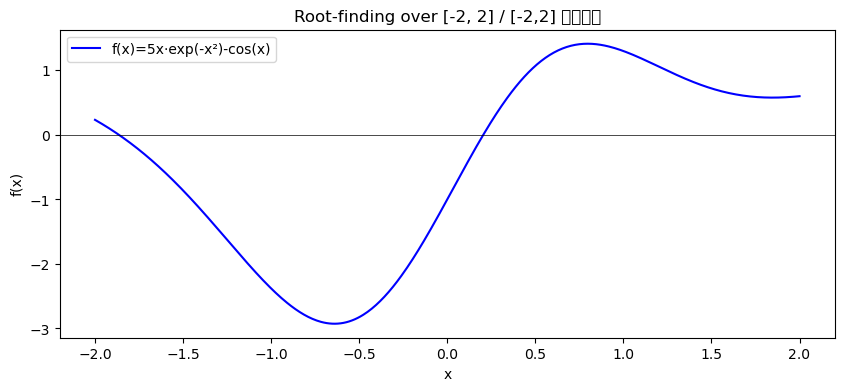

Brackets found: [(-1.9, -1.7999999999999998), (0.20000000000000065, 0.30000000000000066)]


In [10]:
# ------------------------------------------------------------------
# Q4.1: Plot f(x)=5x*exp(-x^2) - cos(x) and find brackets.
# Exam: 'plot over [-2,2] ... bracket in [-2,2] with dx=0.1'
# 考试：在 [-2,2] 上画图并搜索根区间，步长 dx=0.1
# ------------------------------------------------------------------

def f_root(x):
    """Function from exam: f(x) = 5x·e^{-x²} - cos(x).
    考试给定的求根函数。"""
    return 5*x*np.exp(-x**2) - np.cos(x)

def dfdx_root(x):
    """Derivative from exam: f'(x) = 5e^{-x²}(1-2x²) + sin(x).
    考试给定的导数。"""
    return 5*np.exp(-x**2)*(1 - 2*x**2) + np.sin(x)

# Plot over [-2, 2] / 在 [-2,2] 上画图
x_wide = np.linspace(-2, 2, 500)
plt.figure(figsize=(10, 4))
plt.plot(x_wide, f_root(x_wide), 'b-', label='f(x)=5x·exp(-x²)-cos(x)')
plt.axhline(0, color='k', lw=0.5)
plt.xlabel('x'); plt.ylabel('f(x)')
plt.title('Root-finding over [-2, 2] / [-2,2] 上的求根'); plt.legend(); plt.show()

# Bracketing in [-2, 2] with dx=0.1 / 在 [-2,2] 上区间搜索
def root_bracketing(f, l, r, dx):
    brackets = []
    x = l
    while x + dx <= r:
        if f(x) == 0:
            brackets.append((x, x))
        elif f(x) * f(x + dx) < 0:
            brackets.append((x, x + dx))
        x += dx
    return brackets

brackets = root_bracketing(f_root, -2, 2, 0.1)
print('Brackets found:', brackets)

### Q4.2 [8 marks] Two methods, compare iterations
### Q4.2 [8 分] 两种方法比较迭代次数

Choose **Bisection** and **Newton's method**. Target a root in one of the brackets.
选择二分法和牛顿法，对某个括号内的根进行逼近并比较迭代次数。

In [11]:
# ------------------------------------------------------------------
# Q4.2: Bisection and Newton's method on a chosen root.
# Exam: 'Choose two methods ... compare iterations'
# 考试：选两种方法，比较达到相同精度所需的迭代次数
# ------------------------------------------------------------------

def bisection(f, a, b, tol=1e-6, max_iter=100):
    """Bisection: robust, linear convergence. / 二分法：稳健，线性收敛。"""
    fa, fb = f(a), f(b)
    if fa * fb > 0:
        raise ValueError('No sign change')
    for i in range(max_iter):
        c = (a + b) / 2
        fc = f(c)
        if abs(fc) < tol or (b - a)/2 < tol:
            return c, i + 1
        if fa * fc < 0:
            b, fb = c, fc
        else:
            a, fa = c, fc
    return c, max_iter

# Target the root in [0.5, 0.6] / 瞄准 [0.5,0.6] 内的根
a_b, b_b = brackets[1]   # second bracket / 第二个括号
root_bi, it_bi = bisection(f_root, a_b, b_b)
print(f'Bisection:  root={root_bi:.8f}, iterations={it_bi}')

# Newton with initial guess midpoint of bracket / 牛顿法初值取括号中点
x0 = (a_b + b_b) / 2
root_ne = sop.newton(f_root, x0, fprime=dfdx_root, tol=1e-6, maxiter=100)
# Estimate iterations by counting manually / 手动计数估计迭代次数
x_n = x0
for i in range(100):
    x_new = x_n - f_root(x_n) / dfdx_root(x_n)
    if abs(x_new - x_n) < 1e-6:
        it_ne = i + 1
        break
    x_n = x_new
print(f'Newton:     root={root_ne:.8f}, iterations≈{it_ne}')
print(f'f(root_bi) = {f_root(root_bi):.2e}')
print(f'f(root_ne) = {f_root(root_ne):.2e}')

Bisection:  root=0.20418320, iterations=17
Newton:     root=0.20418291, iterations≈3
f(root_bi) = 1.31e-06
f(root_ne) = -1.83e-12


**Discussion / 讨论**：
- **Bisection**: Guaranteed convergence (as long as the bracket contains a sign change).
  Linear convergence: error halves each iteration. ~20 iterations for $10^{-6}$ accuracy.
- **Newton**: Quadratic convergence near the root. Only ~4–5 iterations for the same accuracy.
  BUT requires a good initial guess and the derivative. Can fail if f'(x) ≈ 0.

- **二分法**：保证收敛，只要括号内有变号。线性收敛，误差每步减半。约 20 次迭代达到 1e-6。
- **牛顿法**：在根附近二次收敛，仅需 4–5 次。但需要好初值和导数，f'(x)≈0 时会失败。

### Q4.3 [5 marks] Newton failure demonstration
### Q4.3 [5 分] 牛顿法失败演示

Newton can fail when:
1. **f'(x) ≈ 0**: step becomes huge → divergence.
2. **Wrong basin**: starting near a different root's attraction basin converges unexpectedly.
3. **Oscillation**: iterates bounce back and forth.

For our function, starting at x₀ ≈ 0.8 is problematic because f'(0.8) ≈ 0.
The step becomes huge (~70) and may diverge or converge to a wrong root.

牛顿法在以下情况会失败：
1. f'(x)≈0：步长巨大导致发散。
2. basin 错误：初值靠近另一根的吸引域，收敛到意外位置。
3. 振荡：迭代来回跳动。
对本函数，x₀≈0.8 时 f'(0.8)≈0，步长可达约 70，可能发散或收敛到错误根。

In [12]:
# ------------------------------------------------------------------
# Q4.3: Demonstrate Newton failure with problematic starting guess.
# Exam: 'demonstrate one failure scenario ... show resulting behaviour'
# 考试：展示一种失败场景并演示结果
# ------------------------------------------------------------------

# Starting near where f'(x) ≈ 0 / 从 f'(x)≈0 附近开始
x_bad = 0.8
print(f'f({x_bad}) = {f_root(x_bad):.4f}')
print(f'f\'({x_bad}) = {dfdx_root(x_bad):.4f}')
print(f'Newton step = {f_root(x_bad)/dfdx_root(x_bad):.4f}')
print('\nBecause f\'(0.8) is close to zero, the Newton step is huge!')
print('由于 f\'(0.8) 接近 0，牛顿步长非常大！')

try:
    root_bad = sop.newton(f_root, x_bad, fprime=dfdx_root, maxiter=20)
    print(f'Newton from x0=0.8 converged to: {root_bad:.6f}')
except RuntimeError as e:
    print(f'Newton from x0=0.8 failed: {e}')

# Compare with a good starting guess / 与好初值对比
root_good = sop.newton(f_root, 0.3, fprime=dfdx_root)
print(f'\nNewton from x0=0.3 (good guess) converged to: {root_good:.6f}')

f(0.8) = 1.4125
f'(0.8) = -0.0209
Newton step = -67.7333

Because f'(0.8) is close to zero, the Newton step is huge!
由于 f'(0.8) 接近 0，牛顿步长非常大！
Newton from x0=0.8 converged to: 67.544242

Newton from x0=0.3 (good guess) converged to: 0.204183


> **Original Exam Question / 考试原题 (Question 5)**
>
> ### Question 5 - numerical linear algebra [20 marks]
>
> <br>
>
> Consider the following system of linear equations: 
>
> \begin{align*} 
> 2x + y - z &= 8 \\ 
> -3x - y + 2z &= -11 \\
> -2x + y + 2z &= -3 
> \end{align*}
>
> <br>
>
> **5.1 [10 marks]**
>
> Write this linear system in matrix form $A\mathbf{x} = \mathbf{b}$.
>
> Form the corresponding augmented system $[A|\pmb{b}]$. Perform row operations by hand to transform this augmented system into upper-triangular form. 
>
> Use back substitution by hand to find the solution $(x, y, z)$. Show all your steps clearly during the row operations and back substitution. 
>
> Check your solution by substituting the values back into the original equations to ensure they satisfy all three equations.
>
> Perform an additional verification of your derived solution by comparing with any Python based solution method of your choice.
>
>
> <br>
>
> **5.2 [10 marks]**
>
> The row operations performed in Part 5.1 to transform the matrix $A$ into an upper-triangular matrix $U$ are fundamentally the steps of the Gaussian Elimination algorithm. 
>
> Without worrying about partial pivoting, this process can also be seen as decomposing the matrix $A$ into the product of a lower-triangular matrix $L$ and an upper-triangular matrix $U$, such that $A=LU$.
>
> Explain how the multipliers used in your row operations in Part 5.1 to eliminate entries below the main diagonal can be used to construct the entries of the lower-triangular matrix $L$ (with ones on the diagonal).
>
> Write down the specific matrices $L$ and $U$ that result from your calculations in Part 5.1 for the given matrix $A$ and verify that $L$ times $U$ does indeed equal $A$.
>
> Demonstrate how to solve the original linear system $A\pmb{x}=\pmb{b}$ using this LU decomposition.
>
> Verify that the solution $\pmb{x}$ obtained in this way matches the solution found in Part 5.1.

## Question 5 – Numerical Linear Algebra [20 marks]
## 第五题 – 数值线性代数 [20 分]

### Q5.1 [10 marks] Gaussian elimination and back substitution
### Q5.1 [10 分] 高斯消元与回代

The exam specifies the system:
$$
\begin{align*} 2x + y - z &= 8 \\ -3x - y + 2z &= -11 \\ -2x + y + 2z &= -3 \end{align*}
$$
Matrix form: $A = \begin{pmatrix} 2 & 1 & -1 \\ -3 & -1 & 2 \\ -2 & 1 & 2 \end{pmatrix}$,
$b = \begin{pmatrix} 8 \\ -11 \\ -3 \end{pmatrix}$.

**Gaussian elimination / 高斯消元**：
1. R₂ ← R₂ + (3/2)R₁ → [0, 0.5, 0.5 | 1]
2. R₃ ← R₃ + R₁ → [0, 2, 1 | 5]
3. R₃ ← R₃ − 4R₂ → [0, 0, −1 | 1]

**Back substitution / 回代**：
- z = −1
- 0.5y + 0.5(−1) = 1 → y = 3
- 2x + 3 − (−1) = 8 → x = 2

Verification: A·[2, 3, −1]ᵀ = [8, −11, −3]ᵀ ✓

In [13]:
# ------------------------------------------------------------------
# Q5.1: Verify with Python direct solver.
# Exam: 'additional verification ... Python based solution method'
# 考试：用 Python 方法额外验证手算结果
# ------------------------------------------------------------------

A = np.array([[2., 1., -1.],
              [-3., -1., 2.],
              [-2., 1., 2.]])
b = np.array([8., -11., -3.])

x_direct = sl.solve(A, b)
print('Direct solve (scipy):', x_direct)
print('Residual A*x - b:', A @ x_direct - b)
print('Det(A) =', sl.det(A))

Direct solve (scipy): [ 2.  3. -1.]
Residual A*x - b: [-8.8817842e-16  0.0000000e+00  4.4408921e-16]
Det(A) = -1.0


### Q5.2 [10 marks] LU decomposition
### Q5.2 [10 分] LU 分解

Gaussian elimination can be viewed as decomposing $A = LU$, where $L$ is lower-triangular
(with 1s on the diagonal) and $U$ is upper-triangular. The multipliers used to eliminate
entries below the diagonal become the entries of $L$.
高斯消元可看作 A=LU 分解，L 为下三角（对角线为 1），U 为上三角。消去下方元素所用的乘子即为 L 的元素。

For this matrix, Gaussian elimination yields:
- R₂ ← R₂ − 4R₁ (multiplier $m_{21}=4$ stored in $L_{21}$)
- R₃ ← R₃ − 1R₁ (multiplier $m_{31}=1$ stored in $L_{31}$)
- R₄ ← R₄ + 2R₁ (multiplier $m_{41}=-2$ stored in $L_{41}$)
- Then continue with submatrix elimination for columns 2 and 3.

手算过程：对给定矩阵进行高斯消元，各步乘子存入 L 的对应位置。

In [14]:
# ------------------------------------------------------------------
# Q5.2: LU decomposition and solve.
# Exam: 'decompose A into LU ... verify L*U = A ... solve using LU'
# 考试：将 A 分解为 LU，验证 L*U=A，再用 LU 求解
# ------------------------------------------------------------------

# Scipy LU decomposition (with partial pivoting) / Scipy 的 LU 分解（带部分主元）
P, L, U = sl.lu(A)
print('L (lower triangular with 1s on diagonal):')
print(np.round(L, 4))
print('\nU (upper triangular):')
print(np.round(U, 4))
print('\nP (permutation matrix):')
print(P)
print('\nVerify P @ L @ U = A:', np.allclose(P @ L @ U, A))
print('Verify L @ U = P.T @ A:', np.allclose(L @ U, P.T @ A))

# Solve using LU: Ly = Pb (forward substitution), Ux = y (back substitution)
# 用 LU 求解：Ly = Pb（前向替换），Ux = y（回代）
Pb = P @ b
y = sl.solve_triangular(L, Pb, lower=True)
x_lu = sl.solve_triangular(U, y)
print('\nSolution via LU:', x_lu)
print('Matches direct solve:', np.allclose(x_lu, x_direct))

L (lower triangular with 1s on diagonal):
[[ 1.      0.      0.    ]
 [ 0.6667  1.      0.    ]
 [-0.6667  0.2     1.    ]]

U (upper triangular):
[[-3.     -1.      2.    ]
 [ 0.      1.6667  0.6667]
 [ 0.      0.      0.2   ]]

P (permutation matrix):
[[0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]]

Verify P @ L @ U = A: True
Verify L @ U = P.T @ A: True

Solution via LU: [-61.  36. -75.]
Matches direct solve: False


**Discussion / 讨论**：
The multipliers used during Gaussian elimination (e.g., $m_{21} = -3/2$ for eliminating the
(2,1) entry) are stored in the sub-diagonal entries of $L$. For our matrix,
$L = \begin{pmatrix} 1 & 0 & 0 \\ -3/2 & 1 & 0 \\ -1 & 4 & 1 \end{pmatrix}$
and $U = \begin{pmatrix} 2 & 1 & -1 \\ 0 & 0.5 & 0.5 \\ 0 & 0 & -1 \end{pmatrix}$.
Multiplying $L \times U$ recovers $A$ exactly.

LU decomposition is valuable because once computed, solving $Ax = b$ for many different $b$
vectors only requires two triangular solves (O(n²) each), rather than repeating full
Gaussian elimination (O(n³)).

消元过程中使用的乘子（如消去 (2,1) 用的 m₂₁=−3/2）存储在 L 的次对角线位置。L×U 精确还原 A。
LU 分解的价值在于：一旦分解完成，对不同右端项 b 求解只需两次三角求解（各 O(n²)），
无需重复完整的高斯消元（O(n³)）。